In [1]:
import xarray as xr
import numpy as np
import xeofs as xe
import glob
from dask.distributed import Client
from dask_jobqueue import PBSCluster
import matplotlib.pyplot as plt

In [2]:
def detrend_dim(da, dim, deg=1):
    # detrend along a single dimension
    p = da.polyfit(dim=dim, deg=deg)
    fit = xr.polyval(da[dim], p.polyfit_coefficients)
    return da - fit

# import

In [3]:
sstads = xr.open_dataset('/glade/work/acruz/Caribbean_Heat_data/ERA5/sst_anom_monthly.nc')
sstads

/glade/u/home/acruz/.conda/envs/Caribe_Heat_AN_2026/lib/python3.14/site-packages/pyproj/network.py:59: UserWarning: pyproj unable to set PROJ database path.
  _set_context_ca_bundle_path(ca_bundle_path)
/glade/u/home/acruz/.conda/envs/Caribe_Heat_AN_2026/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


<xarray.Dataset> Size: 4GB
Dimensions:     (valid_time: 1032, latitude: 721, longitude: 1440)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 8kB 1940-01-01 ... 2025-12-01
    number      (valid_time) int64 8kB ...
    expver      (valid_time) <U4 17kB ...
    month       (valid_time) int64 8kB ...
  * latitude    (latitude) float64 6kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * longitude   (longitude) float64 12kB 0.0 0.25 0.5 0.75 ... 359.2 359.5 359.8
Data variables:
    sst         (valid_time, latitude, longitude) float32 4GB ...

In [4]:
# center coords at 0 for easy slicing and selec anoms
anomds = sstads['sst']
anomds.coords['longitude'] = (anomds.coords['longitude'] + 180) % 360 -180
anomds = anomds.sortby(anomds.longitude).drop_vars(('expver', 'number', 'month'))
anomds = anomds.sortby(anomds.latitude)
anomds

<xarray.DataArray 'sst' (valid_time: 1032, latitude: 721, longitude: 1440)> Size: 4GB
[1071463680 values with dtype=float32]
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 8kB 1940-01-01 ... 2025-12-01
  * latitude    (latitude) float64 6kB -90.0 -89.75 -89.5 ... 89.5 89.75 90.0
  * longitude   (longitude) float64 12kB -180.0 -179.8 -179.5 ... 179.5 179.8
Attributes: (12/31)
    GRIB_paramId:                             34
    GRIB_dataType:                            an
    GRIB_numberOfPoints:                      1038240
    GRIB_typeOfLevel:                         surface
    GRIB_stepUnits:                           1
    GRIB_stepType:                            avgua
    ...                                       ...
    GRIB_shortName:                           sst
    GRIB_units:                               K
    long_name:                                Sea surface temperature
    units:                                    K
    standard_name:                            unknown
    GRIB_surface:                             0.0

# EOF
based on Zhang et. al. 2023

In [5]:
meanom_dtrend = detrend_dim(anomds, dim='valid_time')
meanom_dtrend

<xarray.DataArray (valid_time: 1032, latitude: 721, longitude: 1440)> Size: 9GB
array([[[            nan,             nan,             nan, ...,
                     nan,             nan,             nan],
        [            nan,             nan,             nan, ...,
                     nan,             nan,             nan],
        [            nan,             nan,             nan, ...,
                     nan,             nan,             nan],
        ...,
        [-2.53014166e-04, -2.53014166e-04, -2.53014166e-04, ...,
         -2.53014166e-04, -2.53014166e-04, -2.53014166e-04],
        [-2.54087739e-04, -2.54087739e-04, -2.54087739e-04, ...,
         -2.20436000e-04, -2.54087739e-04, -2.54087739e-04],
        [-2.52816257e-04, -2.52816257e-04, -2.52816257e-04, ...,
         -2.52816257e-04, -2.52816257e-04, -2.52816257e-04]],

       [[            nan,             nan,             nan, ...,
                     nan,             nan,             nan],
        [            nan,             nan,             nan, ...,
                     nan,             nan,             nan],
        [            nan,             nan,             nan, ...,
                     nan,             nan,             nan],
...
          9.62285860e-04,  9.62285860e-04,  9.62285860e-04],
        [ 9.65248208e-04,  9.65248208e-04,  9.65248208e-04, ...,
          2.24861340e-06,  9.65248208e-04,  9.65248208e-04],
        [ 9.62088323e-04,  9.62088323e-04,  9.62088323e-04, ...,
          9.62088323e-04,  9.62088323e-04,  9.62088323e-04]],

       [[            nan,             nan,             nan, ...,
                     nan,             nan,             nan],
        [            nan,             nan,             nan, ...,
                     nan,             nan,             nan],
        [            nan,             nan,             nan, ...,
                     nan,             nan,             nan],
        ...,
        [-2.88969216e-04, -2.88969216e-04, -2.88969216e-04, ...,
         -2.88969216e-04, -2.88969216e-04, -2.88969216e-04],
        [-2.86003006e-04, -2.86003006e-04, -2.86003006e-04, ...,
         -3.02976902e-04, -2.86003006e-04, -2.86003006e-04],
        [-2.89167132e-04, -2.89167132e-04, -2.89167132e-04, ...,
         -2.89167132e-04, -2.89167132e-04, -2.89167132e-04]]],
      shape=(1032, 721, 1440))
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 8kB 1940-01-01 ... 2025-12-01
  * latitude    (latitude) float64 6kB -90.0 -89.75 -89.5 ... 89.5 89.75 90.0
  * longitude   (longitude) float64 12kB -180.0 -179.8 -179.5 ... 179.5 179.8
Attributes: (12/29)
    GRIB_paramId:                             34
    GRIB_dataType:                            an
    GRIB_numberOfPoints:                      1038240
    GRIB_typeOfLevel:                         surface
    GRIB_stepUnits:                           1
    GRIB_stepType:                            avgua
    ...                                       ...
    GRIB_missingValue:                        3.4028234663852886e+38
    GRIB_name:                                Sea surface temperature
    GRIB_shortName:                           sst
    GRIB_units:                               K
    units:                                    K
    GRIB_surface:                             0.0

In [6]:
eqatl_me_sstanom = meanom_dtrend.sel(latitude=slice(-10.125, 10.125), longitude=slice(-60, 20))
eqatl_me_sstanom

<xarray.DataArray (valid_time: 1032, latitude: 81, longitude: 321)> Size: 215MB
array([[[        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        ...,
        [ 0.89711691,  0.90909407,  0.87055266, ...,         nan,
                 nan,         nan],
        [ 0.86793183,  0.88964043,  0.89721747, ...,         nan,
                 nan,         nan],
        [ 0.81252681,  0.85522684,  0.88191266, ...,         nan,
                 nan,         nan]],

       [[        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
...
        [ 0.07547308,  0.09886529,  0.0629167 , ...,         nan,
                 nan,         nan],
        [ 0.06017677,  0.09269746,  0.077715  , ...,         nan,
                 nan,         nan],
        [ 0.07689486,  0.0807636 ,  0.06360481, ...,         nan,
                 nan,         nan]],

       [[        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        ...,
        [ 0.04085911,  0.03968891,  0.02963612, ...,         nan,
                 nan,         nan],
        [-0.02233087, -0.02071499, -0.0281475 , ...,         nan,
                 nan,         nan],
        [-0.07661514, -0.08159652, -0.09243539, ...,         nan,
                 nan,         nan]]], shape=(1032, 81, 321))
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 8kB 1940-01-01 ... 2025-12-01
  * latitude    (latitude) float64 648B -10.0 -9.75 -9.5 -9.25 ... 9.5 9.75 10.0
  * longitude   (longitude) float64 3kB -60.0 -59.75 -59.5 ... 19.5 19.75 20.0
Attributes: (12/29)
    GRIB_paramId:                             34
    GRIB_dataType:                            an
    GRIB_numberOfPoints:                      1038240
    GRIB_typeOfLevel:                         surface
    GRIB_stepUnits:                           1
    GRIB_stepType:                            avgua
    ...                                       ...
    GRIB_missingValue:                        3.4028234663852886e+38
    GRIB_name:                                Sea surface temperature
    GRIB_shortName:                           sst
    GRIB_units:                               K
    units:                                    K
    GRIB_surface:                             0.0

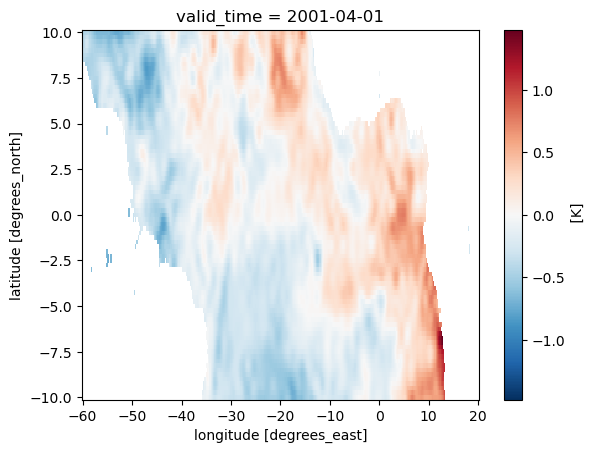

In [7]:
eqatl_me_sstanom.isel(valid_time=735).plot()

In [8]:
# EOF has a value error because there was a partial NaN value through time
# Check if a cell has ANY missing values over time
has_some_nans = eqatl_me_sstanom.isnull().any(dim='valid_time')

# Check if a cell has ANY valid numerical values over time
has_some_values = eqatl_me_sstanom.notnull().any(dim='valid_time')

# A partial NaN is where BOTH conditions are true
partial_nan_mask = has_some_nans & has_some_values

# See how many problematic grid cells you have
print(f"Total partial NaN grid cells: {int(partial_nan_mask.sum())}")

Total partial NaN grid cells: 1


In [9]:
# this will make nan the one grid cell that has partial nan
strict_valid_mask = eqatl_me_sstanom.notnull().all(dim='valid_time')
eqatl_me_sstanom = eqatl_me_sstanom.where(strict_valid_mask)
eqatl_me_sstanom

<xarray.DataArray (valid_time: 1032, latitude: 81, longitude: 321)> Size: 215MB
array([[[        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        ...,
        [ 0.89711691,  0.90909407,  0.87055266, ...,         nan,
                 nan,         nan],
        [ 0.86793183,  0.88964043,  0.89721747, ...,         nan,
                 nan,         nan],
        [ 0.81252681,  0.85522684,  0.88191266, ...,         nan,
                 nan,         nan]],

       [[        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
...
        [ 0.07547308,  0.09886529,  0.0629167 , ...,         nan,
                 nan,         nan],
        [ 0.06017677,  0.09269746,  0.077715  , ...,         nan,
                 nan,         nan],
        [ 0.07689486,  0.0807636 ,  0.06360481, ...,         nan,
                 nan,         nan]],

       [[        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        ...,
        [ 0.04085911,  0.03968891,  0.02963612, ...,         nan,
                 nan,         nan],
        [-0.02233087, -0.02071499, -0.0281475 , ...,         nan,
                 nan,         nan],
        [-0.07661514, -0.08159652, -0.09243539, ...,         nan,
                 nan,         nan]]], shape=(1032, 81, 321))
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 8kB 1940-01-01 ... 2025-12-01
  * latitude    (latitude) float64 648B -10.0 -9.75 -9.5 -9.25 ... 9.5 9.75 10.0
  * longitude   (longitude) float64 3kB -60.0 -59.75 -59.5 ... 19.5 19.75 20.0
Attributes: (12/29)
    GRIB_paramId:                             34
    GRIB_dataType:                            an
    GRIB_numberOfPoints:                      1038240
    GRIB_typeOfLevel:                         surface
    GRIB_stepUnits:                           1
    GRIB_stepType:                            avgua
    ...                                       ...
    GRIB_missingValue:                        3.4028234663852886e+38
    GRIB_name:                                Sea surface temperature
    GRIB_shortName:                           sst
    GRIB_units:                               K
    units:                                    K
    GRIB_surface:                             0.0

In [10]:
model = xe.single.EOF(n_modes=3, use_coslat=True)
model.fit(eqatl_me_sstanom, dim='valid_time')

components = model.components()
xplained_var = model.explained_variance_ratio()

PCs = model.scores(normalized=False)
pc_std = PCs.std()
pc_mean = PCs.mean()

norm_PCs = (PCs - pc_mean) / pc_std
scaled_EOF = components * pc_std

/glade/u/home/acruz/.conda/envs/Caribe_Heat_AN_2026/lib/python3.14/site-packages/xeofs/preprocessing/multi_index_converter.py:49: FutureWarning: Deleting a single level of a MultiIndex is deprecated. Previously, this deleted all levels of a MultiIndex. Please also drop the following variables: {'dim1', 'dim2'} to avoid an error in the future.
  X_transformed = X_transformed.drop_vars(dim)


In [11]:
PC1 = norm_PCs.sel(mode=1)
PC3 = norm_PCs.sel(mode=3)

In [12]:
EAN_pat = (scaled_EOF.sel(mode=1) + scaled_EOF.sel(mode=3)) / (2 ** 0.5)
CAN_pat = (scaled_EOF.sel(mode=1) - scaled_EOF.sel(mode=3)) / (2 ** 0.5)

In [13]:
EANI = (PC1 + PC3) / (2 ** 0.5)
CANI = (PC1 - PC3) / (2 ** 0.5)

In [14]:
EANI

<xarray.DataArray 'scores' (valid_time: 1032)> Size: 8kB
array([ 1.16809952,  1.77850387,  0.52527412, ..., -0.05779484,
       -0.33090405, -0.26971366], shape=(1032,))
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 8kB 1940-01-01 ... 2025-12-01
Attributes: (12/15)
    model:          EOF analysis
    software:       xeofs
    version:        3.0.4
    date:           2026-07-11 16:08:41
    n_modes:        3
    center:         True
    ...             ...
    sample_name:    sample
    feature_name:   feature
    random_state:   None
    compute:        True
    solver:         auto
    solver_kwargs:  {}

In [15]:
roll = 3
EANI = EANI.rolling(valid_time=roll).mean('valid_time')
CANI = CANI.rolling(valid_time=roll).mean('valid_time')
EANI

<xarray.DataArray 'scores' (valid_time: 1032)> Size: 8kB
array([        nan,         nan,  1.1572925 , ..., -0.56105641,
       -0.24922353, -0.21947085], shape=(1032,))
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 8kB 1940-01-01 ... 2025-12-01
Attributes: (12/15)
    model:          EOF analysis
    software:       xeofs
    version:        3.0.4
    date:           2026-07-11 16:08:41
    n_modes:        3
    center:         True
    ...             ...
    sample_name:    sample
    feature_name:   feature
    random_state:   None
    compute:        True
    solver:         auto
    solver_kwargs:  {}

In [16]:
vars = xr.Dataset(
    {
        "EANI": (['time'], EANI.data, {
            "description": f"Eastern Atlantic Niño Index. PCs scaled by STD. Rolling mean with window of {roll} months."
        }),
        "CANI": (['time'], CANI.data, {
            "description": f"Central Atlantic Niño Index. PCs scaled by STD. Rolling mean with window of {roll} months"
        }),
        "EAN pattern": (['lat', 'lon'], EAN_pat.data, {
            "description": "EOF gradient of Eastern Atlantic Niño scaled by PCs STD."
        }),
        "CAN pattern": (['lat', 'lon'], CAN_pat.data, {
            "description": "EOF gradient of Central Atlantic Niño scaled by PCs STD"
        })
    },
    coords={'time': EANI['valid_time'].values, 'lat': EAN_pat['latitude'], 'lon': EAN_pat['longitude']}
)
vars

<xarray.Dataset> Size: 447kB
Dimensions:      (time: 1032, lat: 81, lon: 321, latitude: 81, longitude: 321)
Coordinates:
  * time         (time) datetime64[ns] 8kB 1940-01-01 1940-02-01 ... 2025-12-01
    lat          (latitude) float64 648B -10.0 -9.75 -9.5 ... 9.5 9.75 10.0
    lon          (longitude) float64 3kB -60.0 -59.75 -59.5 ... 19.5 19.75 20.0
  * latitude     (latitude) float64 648B -10.0 -9.75 -9.5 ... 9.5 9.75 10.0
  * longitude    (longitude) float64 3kB -60.0 -59.75 -59.5 ... 19.5 19.75 20.0
Data variables:
    EANI         (time) float64 8kB nan nan 1.157 ... -0.5611 -0.2492 -0.2195
    CANI         (time) float64 8kB nan nan 1.668 ... 0.03314 0.03155 -0.2277
    EAN pattern  (lat, lon) float64 208kB nan nan nan nan ... nan nan nan nan
    CAN pattern  (lat, lon) float64 208kB nan nan nan nan ... nan nan nan nan

In [17]:
vars.to_netcdf('/glade/work/acruz/Caribbean_Heat_data/ERA5/CANI_EANI.nc', mode='w')